In [1]:
import sys
sys.version

'3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]'

In [ ]:
#!pip install crewai
#!pip install crewai_tools
#!pip install langchain-groq
#!pip install sentence-transformers

In [1]:
import crewai_tools
from crewai_tools import PDFSearchTool
from crewai.tools import tool
from crewai import Crew
from crewai import Task
from crewai import Agent
import os
from langchain_openai import ChatOpenAI


In [2]:
# Load API keys
import os

os.environ["GROQ_API_KEY"] = "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"



In [3]:
# Set up the LLM model using Groq's Llama3
from crewai import LLM
llm = LLM(
   model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

In [4]:
#load pdf
from langchain_community.document_loaders import PyPDFLoader


rag_tool = PyPDFLoader(r"C:\Users\Lizzie\project3\crew_data\doc.pdf")
docs = rag_tool.load()

#clean text

def clean_text(text):
    lines = text.split("\n")
    
    cleaned = []
    for line in lines:
        # remove emails, headers, short lines
        if "@" in line:
            continue
        if len(line.strip()) < 30:
            continue
        cleaned.append(line)
    
    return "\n".join(cleaned)

for d in docs:
    d.page_content = clean_text(d.page_content)



#split into chunks

from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200, separators=["\n\n", "\n", ". ", " "])
chunks = splitter.split_documents(docs)

#create huggingface embeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

#remove useless chunks
clean_chunks = []

for c in chunks:
    text = c.page_content.strip()
    
    # remove junk chunks
    if len(text) < 100:
        continue
    if text.isupper():  # titles
        continue
    
    clean_chunks.append(c)

# load second pdf
rag_tool2 = PyPDFLoader(r"C:\Users\Lizzie\project3\crew_data\surg.pdf")
docs2 = rag_tool2.load()

# clean
for d in docs2:
    d.page_content = clean_text(d.page_content)

# split
chunks2 = splitter.split_documents(docs2)

# clean chunks again
clean_chunks2 = []
for c in chunks2:
    text = c.page_content.strip()
    if len(text) < 100:
        continue
    if text.isupper():
        continue
    clean_chunks2.append(c)


#build vector store 
from langchain_community.vectorstores import FAISS

db = FAISS.from_documents(clean_chunks + clean_chunks2, embeddings)

#search pdf
query = "what is this document about?"
results = db.similarity_search(query, k=3)

for r in results:
    print(r.page_content)

C:\Users\Lizzie\AppData\Local\Temp\ipykernel_19256\3685620171.py:39: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Patient information is critical in the delivery of effective care – thousands of practices, tools, and techniques have been
developed in patient interview, health record storage, and physical examination purely for the sake of effective usage of
key patient information. Clinicians must have an effective understanding of a patient – including but not limited to
the history of present illness (HPI), past medical history (PMH), family history (FH), and more. This allows them to
discern accurate differentials and develop efficacious management plans.
In modern healthcare, collected patient information is stored in electronic health records (EHRs), where they lie
unstructured across thousands of progress notes, lab results, office visits, phone call transcriptions, and the like. Clinical
summarization involves condensing this unstructured information into an accurate picture of a patient’s medical history
medical errors and physician burnout.
5 The Role of AI in Clinical Summarization
The g

In [5]:
from crewai.tools import tool
#change it to crewAI tool

@tool
def pdf_search_tool(query: str) -> str:
    """Search the PDF and return relevant context."""
    results = db.similarity_search(query, k=3)
    return "\n\n".join([r.page_content for r in results])

In [6]:
#set up tavily tool for real time web search

from langchain_community.tools.tavily_search import TavilySearchResults
import os

os.environ["TAVILY_API_KEY"] = "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"

web_search_tool = TavilySearchResults(
    k=3,
    tavily_api_key=os.environ["TAVILY_API_KEY"]
)

C:\Users\Lizzie\AppData\Local\Temp\ipykernel_19256\3353124996.py:8: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(


In [7]:
#  Run a web search using the Tavily tool
web_search_tool.run("What does Sporo Health do?")

[{'title': 'Sporo Health | Envolve',
  'url': 'https://envolveglobal.org/envolvexl-portfolio/sporo-health/',
  'content': 'Skip to content\n\n[](\n\n## Sporo Health\n\nLinkedin     Link\n\nSporo Health is an AI research lab for healthcare. Workforce shortages, high AI implementation costs, and slow adoption — along with data security concerns and AI inaccuracies—hinder the scalability and effectiveness of healthcare delivery. Addressing these challenges is essential to enhance efficiency and improve patient outcomes. Searching through hundreds of patient chart documents and puzzle-piecing together a history is time-consuming and difficult – let Sporo do it for you within seconds, focusing on the key elements of a patient’s story in an easily-digestible, familiar, presentation format.\n\nBack\n\nPrevious Company',
  'score': 0.90330297},
 {'title': 'Home - Sporo Health',
  'url': 'https://info.sporo.health/',
  'content': "Dr. Wael Aboughali MD, Family Medicine\n\nI have been a family p

In [8]:
from crewai.tools import tool
from tavily import TavilyClient

tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

@tool("Web Search")
def tavily_search(query: str):
    """Search the web for latest AI trends and news"""
    return tavily.search(query=query, max_results=3)

In [9]:
@tool
def router_tool(question):
  """Router Function"""
  if 'Sporo Health' in question:
    return 'vectorstore'
  else:
    return 'web_search'

In [10]:
#create router agent 
Router_Agent = Agent(
    role="Router",
    goal="Route user question to a vectorstore or web search",
    backstory=(
        "You are an expert at routing user questions. "
        "Use vectorstore for RAG-related queries. "
        "Otherwise use web search."
    ),
    verbose=True,
    allow_delegation=False,
    llm=llm
)

print("Router Agent created successfully!")

Router Agent created successfully!


In [11]:
#create retriever agent 
Retriever_Agent = Agent(
role="Retriever",
goal="Use the information retrieved from the vectorstore to answer the question",
backstory=(
    "You are an assistant for question-answering tasks."
    "Use the information present in the retrieved context to answer the question."
    "You have to provide a clear concise answer."
),
verbose=True,
allow_delegation=False,
llm=llm,
)

In [12]:
#create grader agent
Grader_agent =  Agent(
  role='Answer Grader',
  goal='Filter out erroneous retrievals',
  backstory=(
    "You are a grader assessing relevance of a retrieved document to a user question."
    "If the document contains keywords related to the user question, grade it as relevant."
    "It does not need to be a stringent test.You have to make sure that the answer is relevant to the question."
  ),
  verbose=True,
  allow_delegation=False,
  llm=llm,
)

In [13]:
#create hallucination grader agent
hallucination_grader = Agent(
    role="Hallucination Grader",
    goal="Filter out hallucination",
    backstory=(
        "You are a hallucination grader assessing whether an answer is grounded in / supported by a set of facts."
        "Make sure you meticulously review the answer and check if the response provided is in alignmnet with the question asked"
    ),
    verbose=True,
    allow_delegation=False,
    llm=llm,
)

In [14]:
# create answer grader agent
answer_grader = Agent(
    role="Answer Grader",
    goal="Filter out hallucination from the answer.",
    backstory=(
        "You are a grader assessing whether an answer is useful to resolve a question."
        "Make sure you meticulously review the answer and check if it makes sense for the question asked"
        "If the answer is relevant generate a clear and concise response."
        "If the answer gnerated is not relevant then perform a websearch using 'web_search_tool'"
    ),
    verbose=True,
    allow_delegation=False,
    llm=llm,
)

In [15]:
#define trend analyst agent using tavily search 
trend_analyst = Agent(
    role="Trend Analyst",
    goal="Summarize the latest trends in AI",
    backstory="Expert in analyzing global tech trends",
    tools=[tavily_search],
    llm=llm,
    verbose=True
)

In [16]:
report_agent = Agent(
    role="Report Generator",
    goal="Create structured reports from research findings",
    backstory="Expert technical writer who turns data into clear reports",
    tools=[], # usually NO tools needed
    llm=llm,
    verbose=True
)

In [17]:
# Define the task each agent is responsible for
router_task = Task(
    description=("Analyse the keywords in the question {question}"
    "Based on the keywords decide whether it is eligible for a vectorstore search or a web search."
    "Return a single word 'vectorstore' if it is eligible for vectorstore search."
    "Return a single word 'websearch' if it is eligible for web search."
    "Do not provide any other premable or explaination."
    ),
    expected_output=("Give a binary choice 'websearch' or 'vectorstore' based on the question"
    "Do not provide any other premable or explaination."),
    agent=Router_Agent,
    tools=[router_tool],
)

In [18]:
retriever_task = Task(
    description=("Based on the response from the router task extract information for the question {question} with the help of the respective tool."
    "Use the web_serach_tool to retrieve information from the web in case the router task output is 'websearch'."
    "Use the rag_tool to retrieve information from the vectorstore in case the router task output is 'vectorstore'."
    ),
    expected_output=("You should analyse the output of the 'router_task'"
    "If the response is 'websearch' then use the web_search_tool to retrieve information from the web."
    "If the response is 'vectorstore' then use the rag_tool to retrieve information from the vectorstore."
    "Return a claer and consise text as response."),
    agent=Retriever_Agent,
    context=[router_task],
   #tools=[retriever_tool],
)

In [19]:
grader_task = Task(
    description=("Based on the response from the retriever task for the quetion {question} evaluate whether the retrieved content is relevant to the question."
    ),
    expected_output=("Binary score 'yes' or 'no' score to indicate whether the document is relevant to the question"
    "You must answer 'yes' if the response from the 'retriever_task' is in alignment with the question asked."
    "You must answer 'no' if the response from the 'retriever_task' is not in alignment with the question asked."
    "Do not provide any preamble or explanations except for 'yes' or 'no'."),
    agent=Grader_agent,
    context=[retriever_task],
)

In [20]:
hallucination_task = Task(
    description=("Based on the response from the grader task for the quetion {question} evaluate whether the answer is grounded in / supported by a set of facts."),
    expected_output=("Binary score 'yes' or 'no' score to indicate whether the answer is sync with the question asked"
    "Respond 'yes' if the answer is in useful and contains fact about the question asked."
    "Respond 'no' if the answer is not useful and does not contains fact about the question asked."
    "Do not provide any preamble or explanations except for 'yes' or 'no'."),
    agent=hallucination_grader,
    context=[grader_task],
)


In [21]:
answer_task = Task(
    description=("Based on the response from the hallucination task for the quetion {question} evaluate whether the answer is useful to resolve the question."
    "If the answer is 'yes' return a clear and concise answer."
    "If the answer is 'no' then perform a 'websearch' and return the response"),
    expected_output=("Return a clear and concise response if the response from 'hallucination_task' is 'yes'."
    "Perform a web search using 'web_search_tool' and return ta clear and concise response only if the response from 'hallucination_task' is 'no'."
    "Otherwise respond as 'Sorry! unable to find a valid response'."),
    context=[hallucination_task],
    agent=answer_grader,
    #tools=[answer_grader_tool],
)

In [22]:
trend_task = Task(
    description=(
        "Use the web search tool to find the latest information about AI trends. "
        "Focus on recent developments, breakthroughs, and industry direction. "
        "Summarise the findings in a clear and structured way."
    ),
    expected_output=(
        "A concise summary of the latest AI trends with key bullet points. "
        "Do not include explanations of the process or how the answer was generated."
    ),
    agent=trend_analyst,
    tools=[tavily_search],
)

In [23]:
report_task = Task(
    description=(
        "Take the research from the Trend Analyst and summarise it into a structured report. "
        "Include sections: Overview, Key Trends, Industry Impact, and Conclusion."
    ),
    expected_output=(
        "A well-structured report in markdown format with headings and bullet points."
    ),
    agent=report_agent
)

In [24]:
# Assemble agents into a Crew to collaborate on the task
rag_crew = Crew(
    agents=[Router_Agent, Retriever_Agent, Grader_agent, hallucination_grader, answer_grader, trend_analyst, report_agent],
    tasks=[router_task, retriever_task, grader_task, hallucination_task, answer_task, trend_task, report_task],
    verbose=True,

)

In [25]:
inputs ={"question":"Does Sporo Streamline patient chart reviews?"}

In [26]:
# Start the collaborative process among the agents
result = rag_crew.kickoff(inputs=inputs)

╭──────────────────────────────────────────── ✨ Update Available ✨ ─────────────────────────────────────────────╮
│                                                                                                                 │
│  A new version of CrewAI is available!                                                                          │
│                                                                                                                 │
│  Current version: 1.14.1                                                                                        │
│  Latest version:  1.14.2                                                                                        │
│                                                                                                                 │
│  To update, run: uv sync --upgrade-package crewai                                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 381d9255-8e9f-4e44-baeb-c90719d4ea1c                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Analyse the keywords in the question Does Sporo Streamline patient chart reviews?Based on the keywords   │
│  decide whether it is eligible for a vectorstore search or a web search.Return a single word 'vectorstore' if   │
│  it is eligible for vectorstore search.Return a single word 'websearch' if it is eligible for web search.Do     │
│  not provide any other premable or explaination.                                                                │
│  ID: 4cea0de6-c557-46b3-87b0-aa0a12668589                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Router                                                                                                  │
│                                                                                                                 │
│  Task: Analyse the keywords in the question Does Sporo Streamline patient chart reviews?Based on the keywords   │
│  decide whether it is eligible for a vectorstore search or a web search.Return a single word 'vectorstore' if   │
│  it is eligible for vectorstore search.Return a single word 'websearch' if it is eligible for web search.Do     │
│  not provide any other premable or explaination.                                                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#1) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: router_tool                                                                                              │
│  Args: {'question': 'Does Sporo Streamline patient chart reviews?'}                                             │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Report Generator                                                                                        │
│                                                                                                                 │
│  Task: Take the research from the Trend Analyst and summarise it into a structured report. Include sections:    │
│  Overview, Key Trends, Industry Impact, and Conclusion.                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Report Generator                                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  # Overview                                                                                                     │
│  The trend analyst has provided research on the current state of AI trends, specifically focusing on how AI     │
│  will evolve in 2026. The research highlights the growing importance of AI in various industries and aspects    │
│  of life. Additionally, the context of vectorstore and Sporo, a platform designed to streamline healthcare      │
│  processes, is also considered.                                                                                 │
│                                                                                                                 │
│  # Key Trends                                                                                                   │
│  The research identifies the following key trends for AI in 2026:                                               │
│  * AI becoming a real coworker, not just a chatbot                                                              │
│  * AI-powered teamwork                                                                                          │
│  * Enhanced security measures                                                                                   │
│  * Increased research momentum                                                                                  │
│  * Improved infrastructure efficiency                                                                           │
│  * AI becoming a true partner in various industries and aspects of life                                         │
│  * Top trends include:                                                                                          │
│    + AI integration into daily life                                                                             │
│    + Boosting teamwork and collaboration                                                                        │
│    + Enhancing security measures                                                                                │
│    + Driving research momentum                                                                                  │
│    + Improving infrastructure efficiency                                                                        │
│                                                                                                                 │
│  # Industry Impact                                                                                              │
│  The impact of these trends on various industries will be significant, with AI becoming a crucial tool for:     │
│  * Healthcare: Streamlining patient chart reviews and improving care coordination, as seen with platforms like  │
│  Sporo                                                                                                          │
│  * Research: Enhancing research momentum and driving new discoveries                                            │
│  * Security: Improving security measures and protecting sensitive information                                   │
│  * Infrastructure: Improving efficiency and reducing costs                                                      │
│  * The integration of AI into daily life will also have a profound impact on how industries operate and how     │
│  people interact with technology                       

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Take the research from the Trend Analyst and summarise it into a structured report. Include sections:    │
│  Overview, Key Trends, Industry Impact, and Conclusion.                                                         │
│  Agent: Report Generator                                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 381d9255-8e9f-4e44-baeb-c90719d4ea1c                                                                       │
│  Final Output: # Overview                                                                                       │
│  The trend analyst has provided research on the current state of AI trends, specifically focusing on how AI     │
│  will evolve in 2026. The research highlights the growing importance of AI in various industries and aspects    │
│  of life. Additionally, the context of vectorstore and Sporo, a platform designed to streamline healthcare      │
│  processes, is also considered.                                                                                 │
│                                                                                                                 │
│  # Key Trends                                                                                                   │
│  The research identifies the following key trends for AI in 2026:                                               │
│  * AI becoming a real coworker, not just a chatbot                                                              │
│  * AI-powered teamwork                                                                                          │
│  * Enhanced security measures                                                                                   │
│  * Increased research momentum                                                                                  │
│  * Improved infrastructure efficiency                                                                           │
│  * AI becoming a true partner in various industries and aspects of life                                         │
│  * Top trends include:                                                                                          │
│    + AI integration into daily life                                                                             │
│    + Boosting teamwork and collaboration                                                                        │
│    + Enhancing security measures                                                                                │
│    + Driving research momentum                                                                                  │
│    + Improving infrastructure efficiency                                                                        │
│                                                                                                                 │
│  # Industry Impact                                                                                              │
│  The impact of these trends on various industries will be significant, with AI becoming a crucial tool for:     │
│  * Healthcare: Streamlining patient chart reviews and improving care coordination, as seen with platforms like  │
│  Sporo                                                                                                          │
│  * Research: Enhancing research momentum and driving new discoveries                                            │
│  * Security: Improving security measures and protecting sensitive information                                   │
│  * Infrastructure: Improving efficiency and reducing costs                                                      │
│  * The integration of AI into daily life will also have a profound impact on how industries operate and how     │
│  people interact with technology                      

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [22]:
#explore the vectorstore

#run similarity search to check what the vectorstore prints 

docs = db.similarity_search("AI trends in healthcare", k=3)

for doc in docs:
    print(doc.page_content)

adaptation of clinical workflows are essential factors that must be addressed to achieve seamless integration and
AI in clinical summarization offers transformative potential for healthcare, promising to enhance the efficiency and
accuracy of medical documentation and decision-making. However, realizing this potential requires overcoming
substantial challenges in data management, system integration, and maintaining the ethical standards of patient care.
Future developments in this field must focus on refining AI technologies, improving their adaptability, and ensuring
they align with the overarching goal of improving patient outcomes.
As AI continues to evolve, future research will likely explore more sophisticated models that can handle a wider
range of data types and clinical scenarios. Additionally, the ethical implications of AI in healthcare, such as racial or
socioeconomic bias in AI algorithms and the impact of automation on employment within the healthcare sector, will
socioeco

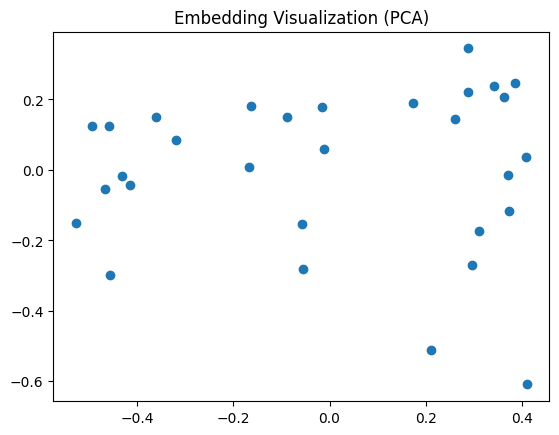

In [23]:
#visualise embeddings 

from sklearn.decomposition import PCA
import matplotlib
import matplotlib.pyplot as plt


embeddings = db.index.reconstruct_n(0, db.index.ntotal)

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.scatter(reduced[:, 0], reduced[:, 1])
plt.title("Embedding Visualization (PCA)")
plt.show()

In [44]:
print(len(docs2))
print(docs2[0].page_content[:500])

2
4 |     Ann Gastroenterol Surg. 2024;8:4–5.
​ Received:​6​December​2023 |  Accepted:​6​December​2023
Artificial intelligence and surgery
 ​ Artificial​intelligence​ (AI)​ has​ a​ significant​ impact​ on​ the​ field​ of​
health​care,​particularly ​imaging​and​video​analyses. ​It​can​consid-
erably​support ​clinical​decision-​making,​including ​the​automatic​di-
agnosis​of​gastrointestinal​ cancer​ during​endoscopy​ and​automated​
detection ​of​pulmonary ​lesions​on​computed​tomography ​(CT).1,2 I


In [70]:
with open("report.md", "w", encoding="utf-8") as f:
    f.write(str(result))

In [71]:
print(str(result))

# Overview
Sporo is a healthcare technology company that aims to streamline clinical workflows and improve patient care through its innovative platform. The platform utilizes artificial intelligence (AI) and natural language processing (NLP) to analyze patient charts, identify relevant information, and provide healthcare providers with quick and easy access to patient data. This report summarizes the key features, benefits, and trends related to Sporo's platform.

# Key Trends
The following are key trends related to Sporo's platform and the broader AI industry:
* Increased adoption of AI in healthcare and other industries
* Growing demand for AI-powered tools that can analyze large amounts of data and provide insights
* Advancements in multimodal AI, which can process and generate multiple forms of data, such as text, images, and speech
* Rising importance of AI in scientific research and discovery
* Growing need for AI to augment human capabilities and improve decision-making
* Top 5 

In [72]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

# extract text
report_text = str(result)

# create pdf
pdf = SimpleDocTemplate("report.pdf")

styles = getSampleStyleSheet()
style = styles["Normal"]

content = []

for line in report_text.split("\n"):
    content.append(Paragraph(line, style))
    content.append(Spacer(1, 5))

pdf.build(content)